## Problem: When arriving at the Doan Hall stop, the bus is already full from the UH stop. 

### Goals:

- Break down boardings and alightings by stop (UH and Doan) in 30 minute intervals 
- Sample data from approximately 4/1/2026 - 4/14/2026
- 2pm - 4pm timeframe initially, can expand to include 9am, etc.

---

Ultimate goal is to determine if full busses are coming TO Doan FROM UH and pinpoint the timeframe of when the problem is occuring.

---

In [ ]:
# Should only have to run 1x here/
from modules import busstate_processing as bp

# Should contain data from 4/1/2026 to present 4/16/2026
bp.busstate_processing(year = "26", month = "04", current_dir = "K:/AP/TTM/Data/WMC_Dashboard/") #stored initial in /analysis_data if needed in future

Starting busstate processing for 04/26...
Found 504 busstate files for 04/26 in 'K:\AP\TTM\Data\APC Data'
Unzipping and processing busstate files for 04/26...
Combined dataframe has 596268 records for 04/26
No data for month JAN 2026
No data for month FEB 2026
Saved 47891 records for MAR 2026 to 'K:\AP\TTM\Data\WMC_Dashboard\busstate_cleaned\busstate_cleaned\2026-MAR-busstate.csv'
Saved 548364 records for APR 2026 to 'K:\AP\TTM\Data\WMC_Dashboard\busstate_cleaned\busstate_cleaned\2026-APR-busstate.csv'
No data for month MAY 2026
No data for month JUN 2026
No data for month JUL 2026
No data for month AUG 2026
No data for month SEP 2026
No data for month OCT 2026
No data for month NOV 2026
No data for month DEC 2026
Finished processing busstate data for 04/26 in 103.78 seconds. Cleaned files saved to 'K:\AP\TTM\Data\WMC_Dashboard\busstate_cleaned\busstate_cleaned'


In [2]:
import pandas as pd
from modules import med_center_dashboard as mcd

# ok - busstate data is stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
# this contains from 4/1/2026 to present

apr_df = pd.read_csv("K:/AP/TTM/Data/WMC_Dashboard/analysis_data/2026-APR-busstate.csv")

apr_mc_df = mcd.process_mc_busstate(year = "2026",month = "APR")

apr_mc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18560 entries, 0 to 18559
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   BUS_ID      18560 non-null  int64          
 1   DATE        18560 non-null  datetime64[us] 
 2   COUNT       18560 non-null  int64          
 3   STOP_ID     18560 non-null  int64          
 4   BOARDINGS   18560 non-null  int64          
 5   ALIGHTINGS  18560 non-null  int64          
 6   LOAD        18560 non-null  int64          
 7   RUN_ID      18560 non-null  float64        
 8   DEST        18560 non-null  str            
 9   ARRIVAL     18560 non-null  datetime64[us] 
 10  DEPARTURE   18560 non-null  datetime64[us] 
 11  DWELL       18560 non-null  timedelta64[us]
 12  HOUR        18560 non-null  int32          
 13  MINUTE      18560 non-null  int32          
dtypes: datetime64[us](3), float64(1), int32(2), int64(6), str(1), timedelta64[us](1)
memory usage: 1.8 MB


In [3]:
# cut down to only doan 37 and UH 401
# should now only have info for UH and Doan stops
uh_doan_apr_mc_df = apr_mc_df[(apr_mc_df['STOP_ID'] == 401) | (apr_mc_df['STOP_ID'] == 37)]

uh_doan_apr_mc_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
4,1303,2026-04-01,5,401,22,2,27,1503.0,MC,1900-01-01 14:06:59,1900-01-01 14:08:18,0 days 00:01:19,14,6
5,1303,2026-04-01,6,37,13,8,32,1503.0,MC,1900-01-01 14:08:51,1900-01-01 14:11:46,0 days 00:02:55,14,8
10,1303,2026-04-01,11,401,11,13,15,1503.0,MC,1900-01-01 14:30:21,1900-01-01 14:32:22,0 days 00:02:01,14,30
11,1303,2026-04-01,12,37,8,7,14,1503.0,MC,1900-01-01 14:32:57,1900-01-01 14:34:21,0 days 00:01:24,14,32
16,1303,2026-04-01,17,401,3,7,5,1503.0,MC,1900-01-01 14:53:41,1900-01-01 14:54:31,0 days 00:00:50,14,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18545,2503,2026-04-14,18536,37,6,1,11,1507.0,MC,1900-01-01 19:08:34,1900-01-01 19:11:40,0 days 00:03:06,19,8
18550,2503,2026-04-14,18541,401,38,2,38,1507.0,MC,1900-01-01 19:28:42,1900-01-01 19:30:23,0 days 00:01:41,19,28
18551,2503,2026-04-14,18542,37,5,1,42,1507.0,MC,1900-01-01 19:30:54,1900-01-01 19:33:39,0 days 00:02:45,19,30
18556,2503,2026-04-14,18547,401,6,1,5,1507.0,MC,1900-01-01 19:49:48,1900-01-01 19:50:46,0 days 00:00:58,19,49


In [4]:
# import visualization libraries
%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Side by side stop comparison

In [12]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
temp = uh_doan_apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))
temp.drop(['DATE', 'ARRIVAL'], axis=1, inplace=True)

# break apart timeframes into 30 min intervals - not keeping date specifically
# temp['BUCKET'] = temp['TIME'].dt.floor('30Min').dt.time

# cut down bucket to hr/min, dont need sec
# true 30-min bucket, no date shown
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
mc_df = temp.copy()
mc_df['NET'] = mc_df['BOARDINGS'] - mc_df['ALIGHTINGS'] # net indicates PER STOP

# this did NOT work at all
# # sort by stop and time and get a "running load"?
# mc_df.sort_values(['TIME'], inplace=True)
# mc_df['RUNNING_LOAD'] = mc_df.groupby('STOP_ID')['NET'].cumsum()

mc_df

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
4,401,22,2,2026-04-01 14:06:59,14:00,20
5,37,13,8,2026-04-01 14:08:51,14:00,5
10,401,11,13,2026-04-01 14:30:21,14:30,-2
11,37,8,7,2026-04-01 14:32:57,14:30,1
16,401,3,7,2026-04-01 14:53:41,14:30,-4
...,...,...,...,...,...,...
18545,37,6,1,2026-04-14 19:08:34,19:00,5
18550,401,38,2,2026-04-14 19:28:42,19:00,36
18551,37,5,1,2026-04-14 19:30:54,19:30,4
18556,401,6,1,2026-04-14 19:49:48,19:30,5


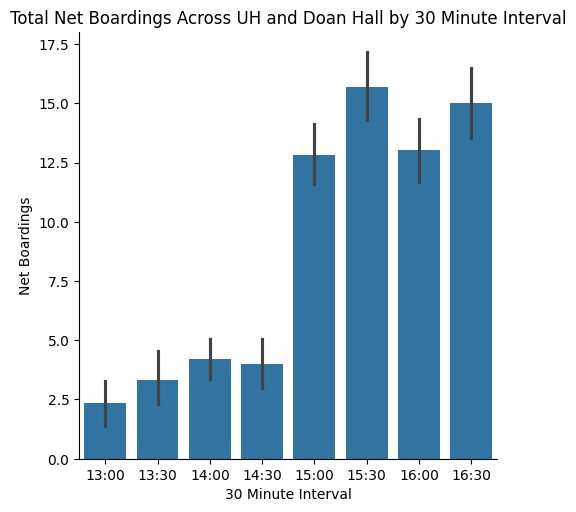

In [13]:
# cut down sample data to doan hall and uh stops separately
# cut down to 1:30pm - 4:30pm for a buffer
mc_df = mc_df[(mc_df['TIME'].dt.time > pd.to_datetime('13:00').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('17:00').time())]
mc_df = mc_df.sort_values(by='TIME')

uh_df = mc_df[mc_df['STOP_ID'] == 401]
doan_df = mc_df[mc_df['STOP_ID'] == 37]


plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'NET',
    kind = 'bar'
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

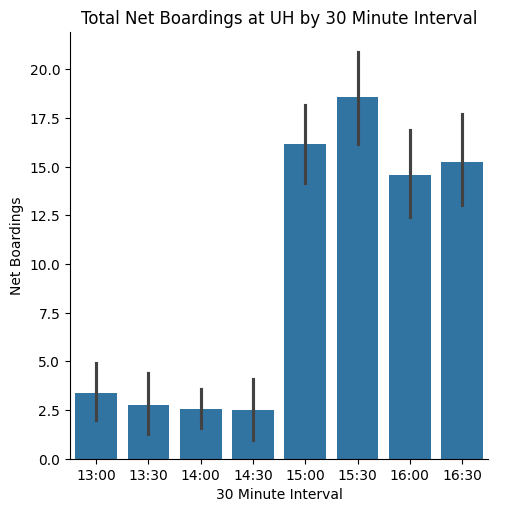

In [14]:
# plot UH individually
plot = sns.catplot(
    data = uh_df,
    x = 'BUCKET',
    y = 'NET',
    kind = 'bar'
)
plot.set(title = "Total Net Boardings at UH by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

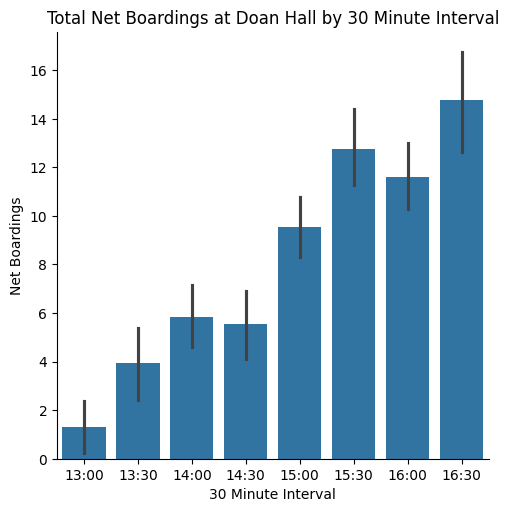

In [15]:
# plot Doan Hall individually
plot = sns.catplot(
    data = doan_df,
    x = 'BUCKET',
    y = 'NET',
    kind = 'bar'
)
plot.set(title = "Total Net Boardings at Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

### NOTES:

- There is a sharp increase overall for net boarding at 1500 for UH, meanwhile there is a more gradual increase in net boardings for Doan 
- this COULD indicate a sharp shift change that is present at UH but not Doan?
- Doan hall also has a lower overall net boardings than UH in this timeframe
- Net is POSITIVE - meaning bus is 'filling' throughout this timeframe